Loading data from D:/Research/Embryo_video/260115_video.csv...
--------------------------------------------------
X Variable      | Y Variable      | Pearson r  | P-value
--------------------------------------------------
Diameter        | Velocity_Abs    | 0.2585     | 4.0357e-03
Area            | Velocity_Abs    | 0.2697     | 2.6596e-03
Diameter        | Velocity_X      | 0.2241     | 1.3090e-02
Area            | Velocity_X      | 0.2258     | 1.2392e-02
--------------------------------------------------
Figure saved to: D:/Research/Embryo_video\nature_style_analysis_4panel.svg


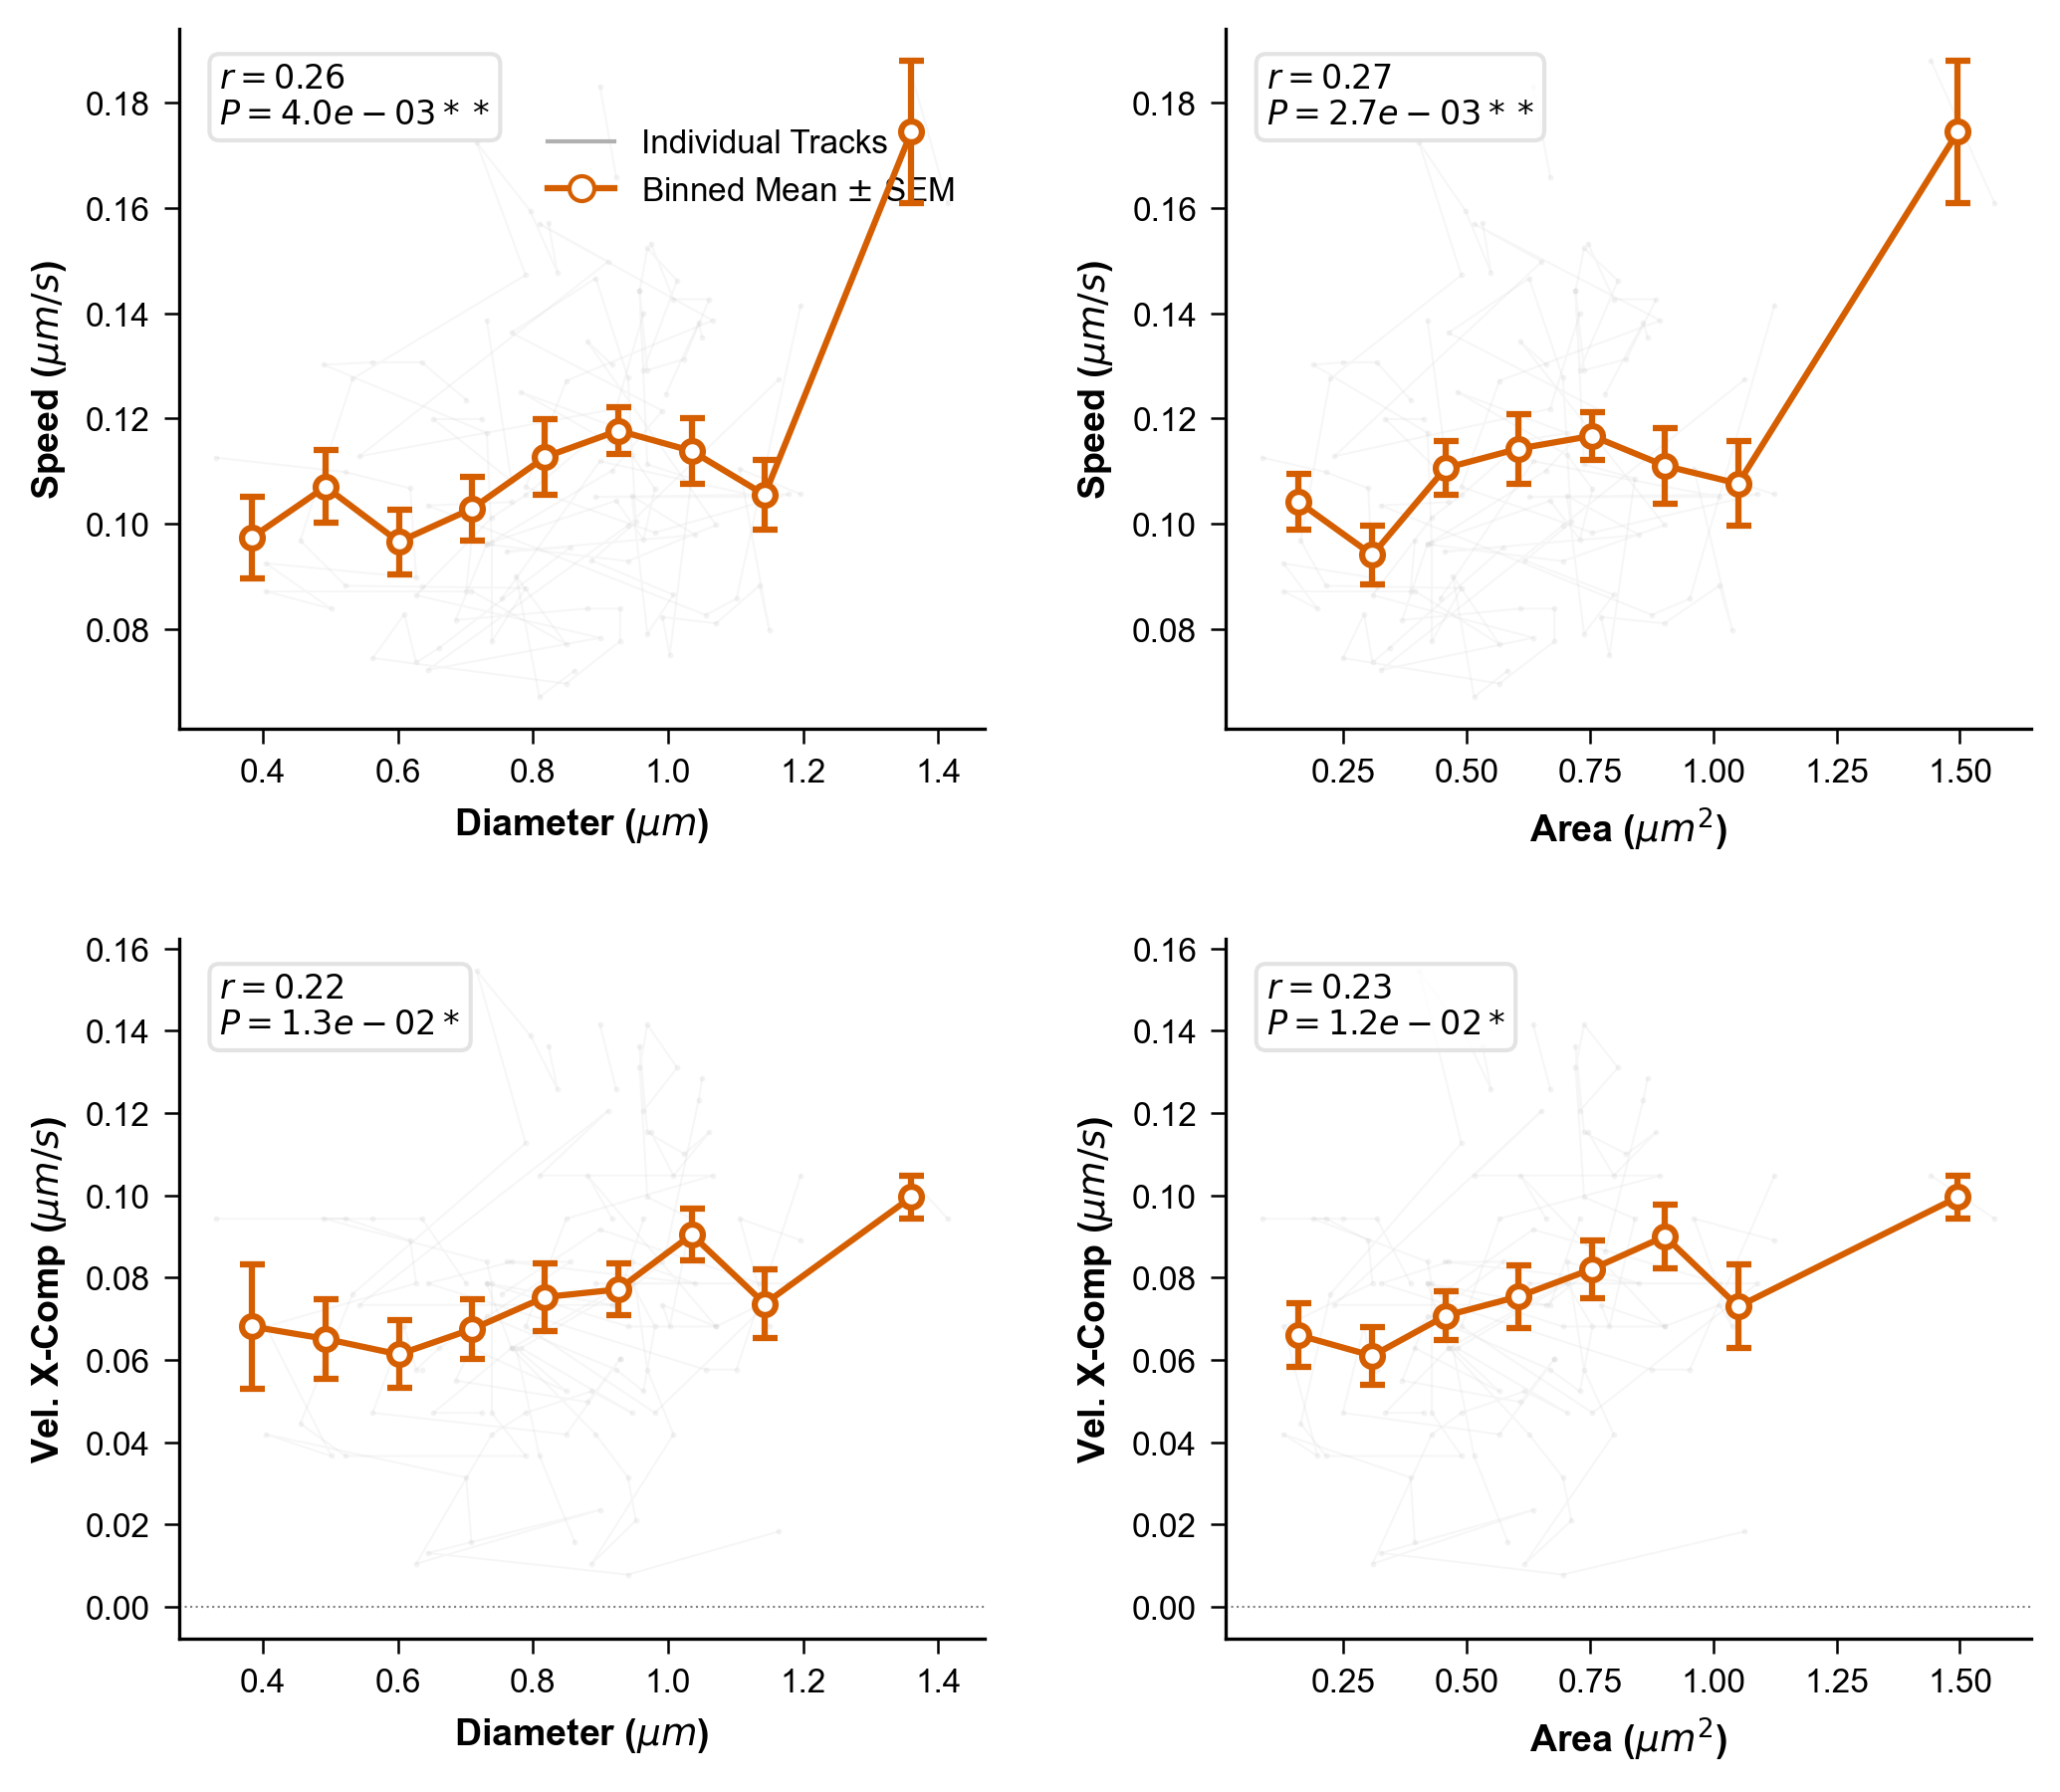

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import os

# ==========================================
# 1. 配置绘图参数 (Nature/Science 极简风格)
# ==========================================
def set_nature_style():
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    plt.rcParams['font.size'] = 8          # 字体调小，精致感
    plt.rcParams['axes.labelsize'] = 9
    plt.rcParams['xtick.labelsize'] = 8
    plt.rcParams['ytick.labelsize'] = 8
    plt.rcParams['axes.linewidth'] = 0.8   # 极细边框
    plt.rcParams['xtick.major.width'] = 0.6
    plt.rcParams['ytick.major.width'] = 0.6
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['savefig.bbox'] = 'tight'

# ==========================================
# 2. 数据处理：加入平滑与分箱逻辑
# ==========================================
def process_data_robust(df, smooth_window=3):
    """
    处理数据，加入滑动平均以减少噪声。
    """
    processed_rows = []
    grouped = df.groupby('TRACK_ID')
    
    for track_id, group in grouped:
        # 按时间排序
        g = group.sort_values('POSITION_T').reset_index(drop=True)
        
        # === 核心改进：先计算原始速度，再平滑 ===
        # 计算位移差 (dX, dY) 和 时间差 (dT)
        d_pos = g[['POSITION_X', 'POSITION_Y']].diff()
        dt = g['POSITION_T'].diff()
        
        # 计算瞬时速度 (原始)
        # 注意：diff后第一行是NaN，需要处理
        v_x = d_pos['POSITION_X'] / dt
        v_y = d_pos['POSITION_Y'] / dt
        v_abs = np.sqrt(v_x**2 + v_y**2)
        
        # === 平滑处理 (Smoothing) ===
        # 使用 rolling mean 减少锯齿状噪声
        if smooth_window > 1:
            v_x = v_x.rolling(window=smooth_window, center=True).mean()
            v_abs = v_abs.rolling(window=smooth_window, center=True).mean()
        
        # 对应的 X轴 属性 (取滑动窗口中心的均值，或者直接取当前值)
        # 这里为了对齐，我们取原始数据的对应行
        
        # 重新组装数据
        temp_df = pd.DataFrame({
            'TRACK_ID': track_id,
            'Time': g['POSITION_T'],
            'Diameter': g['DIAMETER'],
            'Area': g['AREA'],
            'Velocity_Abs': v_abs,
            'Velocity_X': v_x
        })
        
        # 去除因diff和rolling产生的NaN
        temp_df = temp_df.dropna()
        processed_rows.append(temp_df)
            
    return pd.concat(processed_rows)

def calculate_binned_stats(df, x_col, y_col, bins=8):
    """
    核心统计算法：将X轴切分为若干区间，计算每个区间内Y的均值和标准误
    """
    # 创建分箱
    df['bin'] = pd.cut(df[x_col], bins=bins)
    
    # 聚合计算
    stats = df.groupby('bin', observed=True)[y_col].agg(['mean', 'sem', 'count']).reset_index()
    
    # 计算每个箱子的中心位置作为绘图的X坐标
    stats['x_center'] = stats['bin'].apply(lambda x: x.mid).astype(float)
    
    return stats.dropna()

# ==========================================
# 3. 模拟数据生成 (含噪声)
# ==========================================
def generate_noisy_data():
    np.random.seed(123)
    data = []
    n_tracks = 18
    for tid in range(1, n_tracks+1):
        t = np.arange(0, 30, 0.5) # 60帧
        # 假设：直径越大的颗粒，运动越慢 (负相关)
        base_dia = np.random.uniform(1.5, 4.5) 
        
        # 模拟直径波动
        dia = base_dia + np.random.normal(0, 0.1, len(t))
        area = np.pi * (dia/2)**2
        
        # 模拟速度 (带噪声)
        # 真实速度 + 随机噪声
        true_v = 2.0 / dia # 简单的反比关系
        noise = np.random.normal(0, 0.5, len(t))
        
        # 积分得到位置 (为了模拟真实追踪数据)
        v_inst = true_v + noise
        x = np.cumsum(v_inst * 0.5) 
        y = np.random.normal(0, 1, len(t))
        
        for i in range(len(t)):
            data.append([tid, t[i], x[i], y[i], dia[i], area[i]])
            
    return pd.DataFrame(data, columns=['TRACK_ID', 'POSITION_T', 'POSITION_X', 'POSITION_Y', 'DIAMETER', 'AREA'])

# ==========================================
# 4. 绘图核心：背景杂乱线 + 前景统计线 + 相关性分析
# ==========================================
def plot_hybrid_analysis(df, save_dir='.'):
    set_nature_style()
    
    # 定义四个面板 (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(8, 7)) # 宽8英寸，高7英寸
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    
    # 配置列表
    configs = [
        # Row 1: Velocity Magnitude
        {'x': 'Diameter', 'y': 'Velocity_Abs', 'ax': axes[0, 0], 
         'xlab': 'Diameter ($\mu m$)', 'ylab': 'Speed ($\mu m/s$)'},
        {'x': 'Area', 'y': 'Velocity_Abs', 'ax': axes[0, 1], 
         'xlab': 'Area ($\mu m^2$)', 'ylab': 'Speed ($\mu m/s$)'},
        
        # Row 2: Velocity X Component
        {'x': 'Diameter', 'y': 'Velocity_X', 'ax': axes[1, 0], 
         'xlab': 'Diameter ($\mu m$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'},
        {'x': 'Area', 'y': 'Velocity_X', 'ax': axes[1, 1], 
         'xlab': 'Area ($\mu m^2$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'}
    ]
    
    # 颜色
    raw_color = '#B0B0B0'  # 浅灰色用于原始轨迹
    stat_color = '#D55E00' # 朱红色 (Vermilion)
    
    print("-" * 50)
    print(f"{'X Variable':<15} | {'Y Variable':<15} | {'Pearson r':<10} | {'P-value'}")
    print("-" * 50)

    for cfg in configs:
        ax = cfg['ax']
        x_col = cfg['x']
        y_col = cfg['y']
        
        # --- Pearson Correlation ---
        # 计算整组数据的相关性
        clean_data = df[[x_col, y_col]].dropna()
        r, p = pearsonr(clean_data[x_col], clean_data[y_col])
        
        # 打印到控制台
        print(f"{x_col:<15} | {y_col:<15} | {r:.4f}     | {p:.4e}")
        
        # 在图中显示相关系数
        # 根据P值显示星号
        stars = ''
        if p < 0.001: stars = '***'
        elif p < 0.01: stars = '**'
        elif p < 0.05: stars = '*'
        
        stats_text = f"$r = {r:.2f}$\n$P = {p:.1e}{stars}$"
        # 放置在左上角 (transform=ax.transAxes 使用相对坐标)
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                verticalalignment='top', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#dddddd'))

        # --- Layer 1: 原始轨迹 (Raw Spaghetti) ---
        for tid in df['TRACK_ID'].unique():
            sub = df[df['TRACK_ID'] == tid]
            # 为了避免相图中的连线混乱，这里只画微弱的连线，或者只画散点
            # 这里的逻辑是：按时间排序连线，展示轨迹在相空间中的移动
            sub_by_time = sub.sort_values('Time')
            
            ax.plot(sub_by_time[x_col], sub_by_time[y_col], 
                    color=raw_color, alpha=0.1, linewidth=0.5, linestyle='-', zorder=1)
            
            ax.scatter(sub[x_col], sub[y_col], color=raw_color, s=2, alpha=0.15, linewidth=0, zorder=1)

        # --- Layer 2: 分箱统计趋势 (Binned Statistics) ---
        stats = calculate_binned_stats(df, x_col, y_col, bins=10)
        
        ax.errorbar(stats['x_center'], stats['mean'], yerr=stats['sem'], 
                    fmt='-o',             
                    color=stat_color, 
                    linewidth=1.5,        
                    capsize=3,            
                    markersize=5,
                    markerfacecolor='white',
                    markeredgewidth=1.5,
                    zorder=10)            
        
        # --- 装饰 ---
        ax.set_xlabel(cfg['xlab'], fontweight='bold')
        ax.set_ylabel(cfg['ylab'], fontweight='bold')
            
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # X方向速度可能有正负，加一条0参考线
        if 'Velocity_X' in y_col:
            ax.axhline(0, color='black', linewidth=0.5, linestyle=':', alpha=0.5, zorder=0)

    # 统一图例 (放在第一个图里)
    legend_elements = [
        Line2D([0], [0], color=raw_color, lw=1, label='Individual Tracks'),
        Line2D([0], [0], color=stat_color, lw=1.5, marker='o', markerfacecolor='white', label='Binned Mean $\pm$ SEM')
    ]
    axes[0, 0].legend(handles=legend_elements, frameon=False, loc='upper right', bbox_to_anchor=(1.0, 0.9))

    # 保存
    save_path = os.path.join(save_dir, 'nature_style_analysis_4panel.svg')
    plt.savefig(save_path, format='svg')
    print("-" * 50)
    print(f"Figure saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    # 配置输入文件路径
    input_file = 'D:/Research/Embryo_video/260115_video.csv'
    
    # 自动获取目录
    file_dir = os.path.dirname(input_file)
    if not file_dir: file_dir = '.' # 如果路径为空，默认为当前目录
    
    if os.path.exists(input_file):
        print(f"Loading data from {input_file}...")
        raw = pd.read_csv(input_file)
        
        # 处理数据 (平滑窗口=5)
        processed = process_data_robust(raw, smooth_window=5)
        
        # 绘图 (结果保存到同一目录)
        plot_hybrid_analysis(processed, save_dir=file_dir)
        
    else:
        print(f"Warning: File {input_file} not found. Using generated mock data.")
        raw = generate_noisy_data()
        processed = process_data_robust(raw, smooth_window=5)
        plot_hybrid_analysis(processed, save_dir='.')